In [2]:
import os
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.regularizers import l2
import tensorflow as tf
tf.random.set_seed(13)

########## 데이터 로드

def load_data_with_encoded_y(data_dir, width, height):
    x_data = []
    y_data = []
    folder_names = os.listdir(data_dir)
    folder_names = [folder_name for folder_name in folder_names if not folder_name.startswith ('.')] # .DS_Store 제외
    folder_names = folder_names[:]
    for folder_name in folder_names:
        file_names = os.listdir('{}/{}'.format(data_dir, folder_name))
        file_names = [file_name for file_name in file_names if not file_name.startswith ('.')] # .DS_Store 제외
        file_names = file_names[:]
        for file_name in file_names:
            file_path = '{}/{}/{}'.format(data_dir, folder_name, file_name)
            image = Image.open(file_path).convert('L')
            image = image.resize((width, height))
            image = np.array(image) 
            image = image.reshape((width, height, 1))
            x_data.append(image)
            if 'circles' in folder_name:
                y_data.append([1, 0, 0])
            elif 'squares' in folder_name:
                y_data.append([0, 1, 0])
            elif 'triangles' in folder_name:
                y_data.append([0, 0, 1])
    x_data = np.array(x_data)
    y_data = np.array(y_data)

    return x_data, y_data

width = 28
height = 28
color = 1 #색상 채널 수
x_data, y_data = load_data_with_encoded_y('oneday3', width, height)

labels = ['circles', 'squares', 'triangles']

########## 데이터 분석

########## 데이터 전처리

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=13, stratify=y_data)

x_train = x_train
x_test = x_test 
########## 모델 학습
########## 모델 검증

from tensorflow.keras.layers import Dropout, BatchNormalization

input_layer = Input(shape=(width, height, color))

# 첫 번째 컨볼루션 레이어
net = Conv2D(filters=16, kernel_size=(3, 3), strides=(1, 1), padding='same')(input_layer)
net = Activation('relu')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Dropout(0.25)(net) 
# 두 번째 컨볼루션 레이어
net = Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='same')(net)
net = Activation('relu')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)

net = Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding='same')(net)
net = Activation('relu')(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
# 플래튼 레이어
net = Flatten()(net)

# 완전 연결 레이어
net = Dense(units=128, kernel_regularizer=l2(0.001))(net)  # L2 정규화 추가, 0.001은 람다 값
net = BatchNormalization()(net)  # 활성화 함수 전에 배치 정규화 적용
net = Activation('relu')(net)
net = Dropout(0.5)(net)

# 출력 레이어
net = Dense(units=len(labels), kernel_regularizer=l2(0.001))(net)  # 여기에도 L2 정규화 적용
output_layer = Activation('softmax')(net)

model = Model(inputs=input_layer, outputs=output_layer)

2024-02-28 16:53:30.670393: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-28 16:53:30.691806: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-28 16:53:30.692270: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:

model.summary()

model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

hist = model.fit(x_train, y_train, epochs=500, validation_data=(x_test, y_test),batch_size=28, callbacks=[ModelCheckpoint(filepath='model/figure_shape_classification_model.h5', save_best_only=True, verbose=1)])

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 activation (Activation)     (None, 28, 28, 16)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 16)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 14, 14, 16)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 32)        4640      
                                                             

2024-02-28 16:53:42.076051: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2024-02-28 16:53:43.732452: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2024-02-28 16:53:45.474596: I external/local_xla/xla/service/service.cc:168] XLA service 0x563316736420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-02-28 16:53:45.474616: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2024-02-28 16:53:45.479761: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1709106825.563363   69682 device_compiler.h:186] Compiled cluster us

7/7 [==============================] - ETA: 0s - loss: 1.8771 - accuracy: 0.4086 
Epoch 1: val_loss improved from inf to 14.79907, saving model to model/figure_shape_classification_model.h5
7/7 [==============================] - 6s 123ms/step - loss: 1.8771 - accuracy: 0.4086 - val_loss: 14.7991 - val_accuracy: 0.3625
Epoch 2/500
1/7 [===>..........................] - ETA: 0s - loss: 1.4185 - accuracy: 0.4286
Epoch 2: val_loss improved from 14.79907 to 14.60443, saving model to model/figure_shape_classification_model.h5
7/7 [==============================] - 0s 12ms/step - loss: 1.5339 - accuracy: 0.4194 - val_loss: 14.6044 - val_accuracy: 0.3625
Epoch 3/500
1/7 [===>..........................] - ETA: 0s - loss: 1.7672 - accuracy: 0.3929
Epoch 3: val_loss improved from 14.60443 to 14.00593, saving model to model/figure_shape_classification_model.h5
7/7 [==============================] - 0s 12ms/step - loss: 1.6216 - accuracy: 0.4570 - val_loss: 14.0059 - val_accuracy: 0.3625
Epoch 4/50

/home/addinedu/venv/python_venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 4: val_loss improved from 14.00593 to 13.14067, saving model to model/figure_shape_classification_model.h5
7/7 [==============================] - 0s 12ms/step - loss: 1.2866 - accuracy: 0.4946 - val_loss: 13.1407 - val_accuracy: 0.3625
Epoch 5/500
1/7 [===>..........................] - ETA: 0s - loss: 1.6610 - accuracy: 0.4643
Epoch 5: val_loss improved from 13.14067 to 12.04931, saving model to model/figure_shape_classification_model.h5
7/7 [==============================] - 0s 12ms/step - loss: 1.3323 - accuracy: 0.5323 - val_loss: 12.0493 - val_accuracy: 0.3625
Epoch 6/500
1/7 [===>..........................] - ETA: 0s - loss: 1.2730 - accuracy: 0.4643
Epoch 6: val_loss improved from 12.04931 to 10.66017, saving model to model/figure_shape_classification_model.h5
7/7 [==============================] - 0s 12ms/step - loss: 1.1704 - accuracy: 0.5753 - val_loss: 10.6602 - val_accuracy: 0.3625
Epoch 7/500
1/7 [===>..........................] - ETA: 0s - loss: 1.1359 - accuracy: 0

In [4]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


3/3 [==============================] - 0s 57ms/step - loss: 0.3551 - accuracy: 0.9250
Test Loss: 0.35511618852615356
Test Accuracy: 0.925000011920929


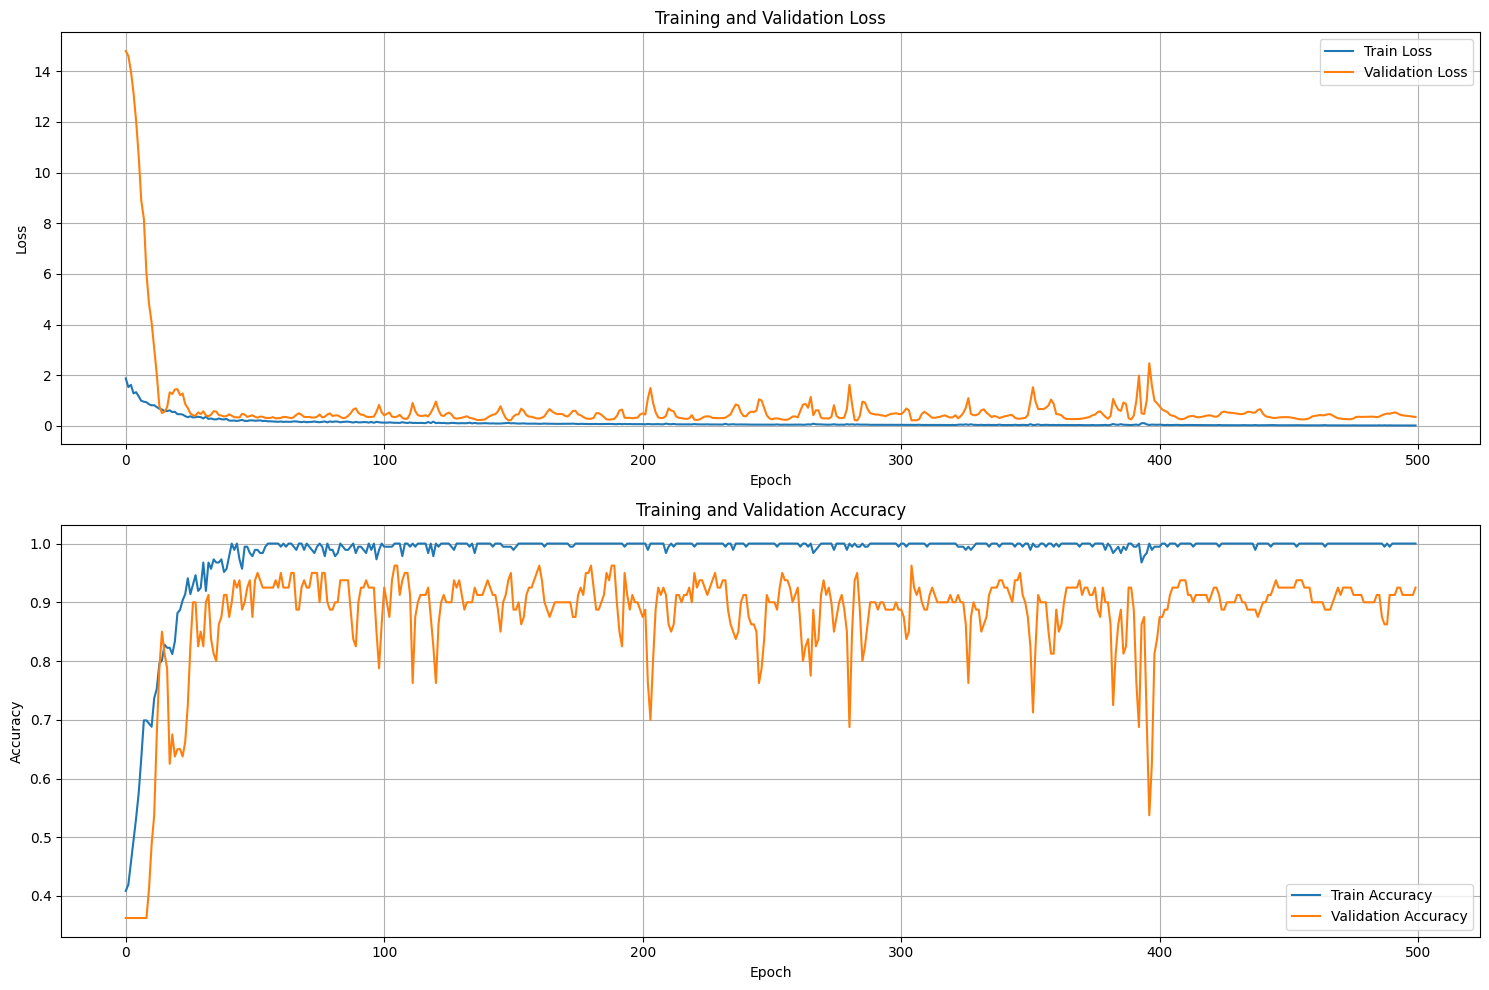

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

# Loss와 accuracy를 플롯할 subplot 생성
plt.figure(figsize=(15, 10))

# Loss subplot
plt.subplot(2, 1, 1)
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Accuracy subplot
plt.subplot(2, 1, 2)
plt.plot(hist.history['accuracy'], label='Train Accuracy')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# 그래프 출력
plt.tight_layout()
plt.show()


1/1 [==============================] - 0s 13ms/step


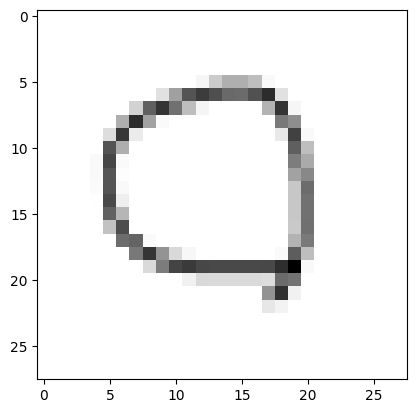

circle


In [34]:
from PIL import Image
import numpy as np
import tensorflow as tf

file_path = '/home/addinedu/amr_ws/MachineLearning/src/drawn_picture.png'  # 파일의 경로로 변경
image = Image.open(file_path).convert('L')

width = height = 28  # 적절한 이미지 크기로 변경
image = image.resize((width, height))

color = 1  # 흑백 이미지이므로 채널 수를 1로 변경
image = np.array(image) 
image = image.reshape((width, height, color))

x_test = [image]
x_test = np.array(x_test)
# 모델 예측
y_predict = model.predict(x_test)


plt.imshow(image,cmap="gray")
plt.show()
print(labels[y_predict.argmax(axis=1)[0]][:-1]) #B